# Accelerating model inference on NVIDIA Tesla T4 with ONNX Runtime

_The notebook used to train this model is available on [GitHub](https://github.com/DonaldKellett/my-ascend-notebooks/blob/7142283969c83027cdb5586c7135d91711e9b6dd/orangepiaipro-20t/11-cifar10-mindspore-v3/00-train-save.ipynb)._

[Open Neural Network Exchange \(ONNX\)](https://onnx.ai/) is an open format built to represent machine learning models. It is used by popular deep learning frameworks such as [MindSpore](https://www.mindspore.cn/), [PyTorch](https://pytorch.org/) and [TensorFlow](https://www.tensorflow.org/) to export machine learning models trained by these frameworks into the portable, unified and vendor-neutral ONNX format. This allows exported models to be loaded by any compatible framework or runtime for inference instead of being locked in to a single framework or provider.

In this notebook experiment, we will load an ONNX model trained on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset mounted at `/kaggle/input/models/donaldsebleung/cifar10-lenet/other/default/1/cifar10-lenet.onnx` and serve it with [ONNX Runtime](https://onnxruntime.ai/) for inference. ONNX Runtime is a cross-platform inference accelerator for ONNX models developed by Microsoft under the permissive MIT license.

## Installing dependent packages

We'll need the ONNX Runtime 1.25.1 with the GPU execution provider \(EP\) for this notebook experiment.

Let's install the required packages with `pip`.

In [1]:
%pip install onnxruntime-gpu==1.25.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 6.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## Loading our ONNX model

Our trained ONNX model is available locally and mounted under the path `/kaggle/input/models/donaldsebleung/cifar10-lenet/other/default/1/cifar10-lenet.onnx`.

In [2]:
import os

model_path = '/kaggle/input/models/donaldsebleung/cifar10-lenet/other/default/1/cifar10-lenet.onnx'
os.path.isfile(model_path)

True

## Serving our model with ONNX Runtime

The `onnxruntime-gpu` Python package allows us to serve ONNX models for inference with GPU acceleration. Let's list the available execution providers \(EP\) with [`onnxruntime.get_available_providers`](https://onnxruntime.ai/docs/api/python/api_summary.html#onnxruntime.get_available_providers) to confirm this.

In [3]:
import onnxruntime as ort

available_providers = ort.get_available_providers()
available_providers, 'CUDAExecutionProvider' in available_providers

(['TensorrtExecutionProvider',
  'CUDAExecutionProvider',
  'CPUExecutionProvider'],
 True)

The output includes `CUDAExecutionProvider` which is what we will be using in this notebook experiment. Alternatively, we could use `TensorrtExecutionProvider` instead which is out of scope for this notebook experiment.

Load our ONNX model and create an [InferenceSession](https://onnxruntime.ai/docs/api/python/api_summary.html#inferencesession) with the CUDA EP.

In [4]:
session = ort.InferenceSession(model_path, providers=['CUDAExecutionProvider'])
providers = session.get_providers()
providers

['CUDAExecutionProvider', 'CPUExecutionProvider']

## Loading the CIFAR-10 dataset with Pickle

Now that our ONNX model is loaded and ready for inference, let's load our data with [Pickle](https://docs.python.org/3/library/pickle.html), the default object serialization library included within Python itself.

In [5]:
import tarfile
import urllib.request

cifar10_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
dataset_dir = 'data/'

with urllib.request.urlopen(cifar10_url) as response:
    with tarfile.open(fileobj=response, mode='r|gz') as tar:
        tar.extractall(path=dataset_dir, filter='data')

dataset_dir = os.path.join(dataset_dir, 'cifar-10-batches-py/')
dataset_dir

'data/cifar-10-batches-py/'

In [6]:
import pickle

test_batch_file_path = os.path.join(dataset_dir, 'test_batch')
test_batch = None
with open(test_batch_file_path, 'rb') as file:
    test_batch = pickle.load(file, encoding='bytes')
test_batch.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [7]:
images = test_batch.get(b'data')
labels = test_batch.get(b'labels')
samples_count = len(labels)
images.shape, samples_count

((10000, 3072), 10000)

The images are given as a Numpy array of $10,000$ samples of $3 \times 32 \times 32 = 3072$ input features, while the labels are given as a Python list of $10,000$ integers in the range $[0, 10)$ corresponding to the 10 categories.

Let's reshape the 10k images to their original dimensions `(32, 32, 3)` and wrap our labels in a Numpy array for convenience.

In [8]:
import numpy as np

images, labels = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1), np.array(labels)
images.shape, labels.shape

((10000, 32, 32, 3), (10000,))

Let's shuffle our test set, then take the first 10 images and visualize them with Matplotlib.

In [9]:
rng = np.random.default_rng()
indices = rng.permutation(samples_count)
images, labels = images[indices], labels[indices]
X_samples, y_samples = images[:10], labels[:10]
X_samples.shape, y_samples.shape

((10, 32, 32, 3), (10,))

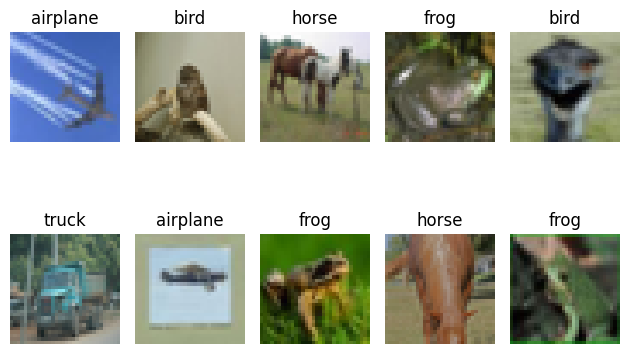

In [10]:
import matplotlib.pyplot as plt

LABELS = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(LABELS[y_samples[axis_idx]])
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

## Transforming our data and performing model inference

Our model accepts as input pre-processed images transformed via the standard procedure described below.

1. Resize each image to $32 \times 32$ pixels. This should already be the case but better safe than sorry ;-\)
1. Rescale each channel from integer in range $[0, 255]$ to float in range $[0, 1]$
1. Reshape each image from dimensions `(height, width, channel)` to `(channel, height, width)`

We'll use [Pillow](https://pillow.readthedocs.io/en/stable/) for the image resizing operation in \(1\) and standard Numpy operations for the rest. Pillow is the de-facto standard for image processing in Python.

In [11]:
import PIL

X_samples_transformed = []

for i in range(len(X_samples)):
    img = PIL.Image.fromarray(X_samples[i])
    img = img.resize((32, 32), PIL.Image.BILINEAR)
    img = np.array(img) / 255
    img = img.transpose(2, 0, 1)
    X_samples_transformed.append(img)

X_samples_transformed = np.stack(X_samples_transformed, axis=0)
X_samples_transformed.shape

(10, 3, 32, 32)

Now that our images are in the correct shape expected by our model, let's pass them to our model for inference.

In [12]:
# Only 1 input in our ONNX model named 'image' defined at model export time
input_name = session.get_inputs()[0].name
input_name

'image'

In [13]:
X_samples_transformed = X_samples_transformed.astype(dtype=np.float32)
y_hat = []

for i in range(len(X_samples_transformed)):
    y_hat.append(session.run(None, {input_name: X_samples_transformed[i:i+1]}))

y_hat = np.squeeze(np.stack(y_hat, axis=0))
y_hat.shape

(10, 10)

Our model outputs raw logits. Transform them to concrete category predictions via the 2-step process below.

1. Apply softmax activation to the logits. This transforms the returned values to probabilities that sum up to 1
1. Use `argmax` to select the most probable category based on the predicted outcomes

Fortunately, since softmax is monotonic and preserves ordering, we can safely skip \(1\) entirely and apply `argmax` directly to the raw logits.

In [14]:
y_hat = np.argmax(y_hat, axis=1)
y_hat, y_samples

(array([0, 2, 7, 6, 2, 9, 0, 6, 7, 3]), array([0, 2, 7, 6, 2, 9, 0, 6, 7, 6]))

Visualize the predictions against the expected labels. Our model performs slightly better than random guessing but you get the idea \(-:

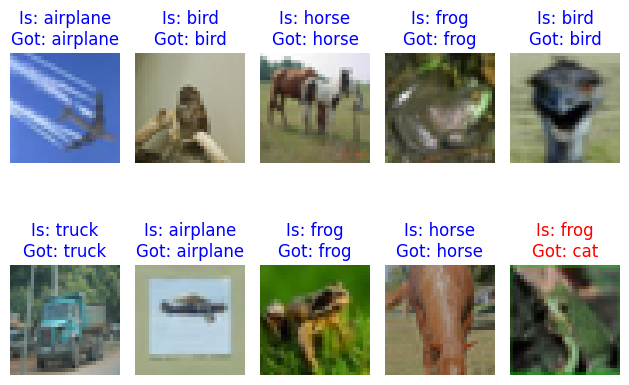

In [15]:
fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    color = 'blue' if y_samples[axis_idx] == y_hat[axis_idx] else 'red'
    axis.set_title(f'Is: {LABELS[y_samples[axis_idx]]}\nGot: {LABELS[y_hat[axis_idx]]}', color=color)
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

## Concluding remarks and going further

We saw in this notebook experiment how to:

1. Load and serve existing ONNX models with ONNX Runtime
1. Accelerate model inference on NVIDIA GPUs with the CUDA EP
1. Deserialize test data with Pickle
1. Visualize our data with Matplotlib
1. Transform our images with Pillow and Numpy for model inference
1. Interpret our model predictions against expected outcomes

I hope you enjoyed following this notebook experiment as much as I did authoring it and stay tuned for updates ;-\)